In [145]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [16]:
# ETAPA 1: Cargar y explorar el dataset
X_pos224 = np.load('X_SES_COVID_POSITIVE_224_Normal.npy')
print(X_pos224.shape) 
# 2604 imagenes
# cada umagen mide 224x224
print(X_pos224)

(2604, 224, 224)
[[[    0     0     0 ... 13667 14126 14441]
  [    0     0     0 ... 13353 13701 13895]
  [    0     0     0 ... 13111 13305 13745]
  ...
  [ 2702  2968  3357 ...     0     0     0]
  [ 2649  2859  3381 ...     0     0     0]
  [ 2391  3023  3402 ...     0     0     0]]

 [[    0     0     0 ...     0     0     0]
  [    0     0     0 ...     0     0     0]
  [    0     0     0 ...     0     0     0]
  ...
  [    0     0     0 ...     0     0     0]
  [    0     0     0 ...     0     0     0]
  [    0     0     0 ...     0     0     0]]

 [[    0     0     0 ...     0     0     0]
  [    0     0     0 ...     0     0     0]
  [    0     0     0 ...     0     0     0]
  ...
  [    0     0     0 ... 11959 11732 11539]
  [    0     0     0 ... 11659 11691 11390]
  [    0     0     0 ... 11698 11777 11257]]

 ...

 [[    0     1    61 ...     0     0     0]
  [    0     0    40 ...     0     0     0]
  [    0     0    31 ...     0     0     0]
  ...
  [    0     0     0 ..

In [17]:
#X_pos600 = np.load('X_SES_COVID_POSITIVE_600_Normal.npy')
#print(X_pos600.shape)
# 2600 imagenes
# cada imagen mide 600x600
#print(X_pos600)

In [18]:
# contar imagenes
num_pos224 = X_pos224.shape[0]
num_pos224

2604

In [19]:
# verificar tamaño de la imagen
print(X_pos224[0].shape)

(224, 224)


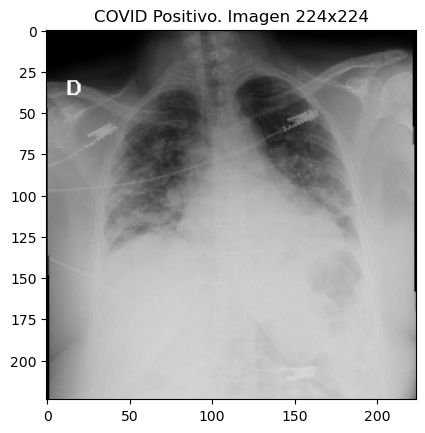

In [20]:
# mostrar imagenes 224x224
plt.imshow(X_pos224[100], cmap='grey')
plt.title('COVID Positivo. Imagen 224x224')
#plt.axis('off')
plt.show()

In [21]:
# mostrar imagenes 600x600
#plt.imshow(X_pos600[0], cmap='grey')
#plt.title('COVID Positivo. Imagen 600x600')
#plt.axis('off')
#plt.show()

In [24]:
# vamos a trabajar con la version 224x224 px para reduir el costo computacional de las 
# etapas de vectorizacion.
X_neg224 = np.load("X_SES_COVID_NEGATIVE_224_Normal.npy")
print(X_neg224.shape)
print(X_neg224)

(1987, 224, 224)
[[[  868   513   351 ...   186   344   699]
  [  665   409   241 ...   149   310   670]
  [  589   343   194 ...   145   280   624]
  ...
  [10474  6502  3257 ... 11900 12520 12692]
  [12385 10624  6624 ... 13224 13373 13280]
  [11953 12306 10758 ... 13056 12939 12906]]

 [[    0    10     9 ...    51    55    45]
  [    0    11     7 ...    33    32    31]
  [    0     6     6 ...    21    21    18]
  ...
  [   13     7     7 ...     3     3     0]
  [   14     7     7 ...     4     4     0]
  [   10     7     8 ...     4     4     0]]

 [[   45    19    12 ...    19    11     0]
  [   56    27    12 ...    70    70     0]
  [   63    26    13 ...    95    84     0]
  ...
  [    0 10103  9326 ...  9113  8967  8638]
  [    0 10306  9545 ...  9784  9754  9184]
  [    0 10471  9935 ... 10502 10548 10077]]

 ...

 [[    1     1     1 ...   197   226   198]
  [    1     1     1 ...   212   188   214]
  [    1     1     1 ...  1073   352   193]
  ...
  [   79    89   138 ..

In [25]:
# contar imagenes
num_neg224 = X_neg224.shape[0]
num_neg224

1987

In [26]:
# verificar tamaño de la imagen
print(X_pos224[0].shape)

(224, 224)


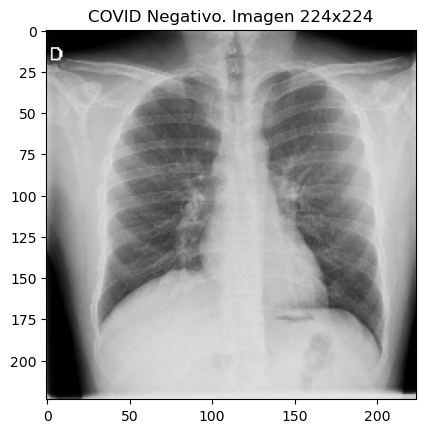

In [27]:
# mostrar imagenes 224x224
plt.imshow(X_neg224[0], cmap='grey')
plt.title('COVID Negativo. Imagen 224x224')
#plt.axis('off')
plt.show()

In [28]:
# unir todo el dataset
x_pos = np.ones(X_pos224.shape[0])
x_neg = np.zeros(X_neg224.shape[0])

In [29]:
x = np.concatenate((X_pos224, X_neg224))
y = np.concatenate((x_pos, x_neg))

In [30]:
x.shape

(4591, 224, 224)

In [31]:
y.shape

(4591,)

In [32]:
# verificar distribucion de clases
df = pd.DataFrame({
    "label":y
})

print(df["label"].value_counts())
# imagenes COVID+ 2604
# imagenes COVID- 1987

# Total 4591
# tamaño de imagen 224x224

label
1.0    2604
0.0    1987
Name: count, dtype: int64


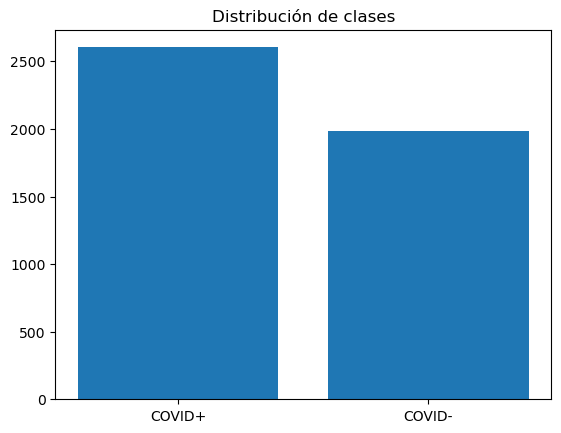

In [33]:
plt.bar(["COVID+","COVID-"], [num_pos224,num_neg224])
plt.title("Distribución de clases")
plt.show()

In [34]:
print(x.dtype) # cada pixel esta almacenado en 16 bits sin signo (vint16)
print(x.shape) # 4591 radiografias donde c/u mide 224x224 px
print(x.min()) # los niveles de gris van de 0 a 16383 (14 bits efectivos)
print(x.max())

uint16
(4591, 224, 224)
0
16383


In [37]:
# ETAPA 2: Preprocesamiento
# PARTE A: normalizar
# para que las variables queden en la misma escala, algo fundamental para PCA y SVD
X_procesado = x.astype(np.float32) / 16383.0



MemoryError: Unable to allocate 879. MiB for an array with shape (4591, 224, 224) and data type float32

In [38]:
print(X_procesado.min())
print(X_procesado.max())

NameError: name 'X_procesado' is not defined

In [36]:
plt.imshow(X_procesado[0], cmap="gray")
plt.title("Imagen preprocesada")
plt.axis("off")
plt.show()

NameError: name 'X_procesado' is not defined

In [166]:
# ETAPA 2, PARTE A.1: Limpieza de imágenes corruptas/vacías
brillo_por_imagen = X_procesado.reshape(X_procesado.shape[0], -1).mean(axis=1)
malas = np.where(brillo_por_imagen < 0.05)[0]   # ajusta el umbral si hace falta
print("Imágenes corruptas detectadas:", len(malas))
print("Distribución de clase entre las corruptas:")
print(pd.Series(y[malas]).value_counts())

X_procesado = np.delete(X_procesado, malas, axis=0)
y = np.delete(y, malas, axis=0)

print("Nuevo shape de X_procesado:", X_procesado.shape)
print("Nuevo shape de y:", y.shape)

Imágenes corruptas detectadas: 305
Distribución de clase entre las corruptas:
1.0    305
Name: count, dtype: int64
Nuevo shape de X_procesado: (4286, 224, 224)
Nuevo shape de y: (4286,)


In [167]:
# PARTE B: Redimensionamiento
# verificamos
X_vectores = X_procesado.reshape(X_procesado.shape[0],-1)
X_vectores.shape

(4286, 50176)

In [168]:
pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [169]:
import cv2
# Yo avanzaría a la ETAPA 3 sin redimensionar 
# y evaluaría el rendimiento (si mi compu soporta la matriz 224x244) 
# antes de reducir resolución.
x.shape
# se redimensiona individualmente

# METODO 2: lISTA COMPREHENSION

"""
# METODO 1: USAMOS EL BUCLE FOR
import numpy as np
X_redimensionado = []

for img in X_procesado:
    nuevo_img = cv2.resize(img, (128,128))
    X_redimensionado.append(nueva_img)
X_redimensionado = np.array(X_redimensionado)
print(X_redimensionado.shape)
"""
X_redimensionado = np.array([
    cv2.resize(img, (128,128))
    for img in X_procesado
])
print(X_redimensionado.shape)


(4286, 128, 128)


In [170]:
# ETAPA 3: vectorizar

# REDIMENSIONADO
X_vectores = X_redimensionado.reshape(
    X_redimensionado.shape[0],
    -1
)
"""
# SIN REDIMENSIONAR
X_vectores = X_procesado.reshape(
    X_procesado.shape[0],-1)

"""
X_vectores.shape 
# 4591 -> cada fila es una radiografia
# 50176 -> un pixel por caracteristica
# cada imagen fue tranformada de una matriz 224 x224 a un vector 50176 x 1


(4286, 16384)

In [171]:
# ETAPA 4: División entrenamiento/prueba
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_vectores,
    y,
    test_size=0.2,      # 20% para prueba, 80% para entrenamiento
    stratify=y,         # mantiene la misma proporción de COVID+/COVID- en ambos conjuntos
    random_state=42     # semilla fija, para que el resultado sea reproducible
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3428, 16384)
X_test: (858, 16384)
y_train: (3428,)
y_test: (858,)


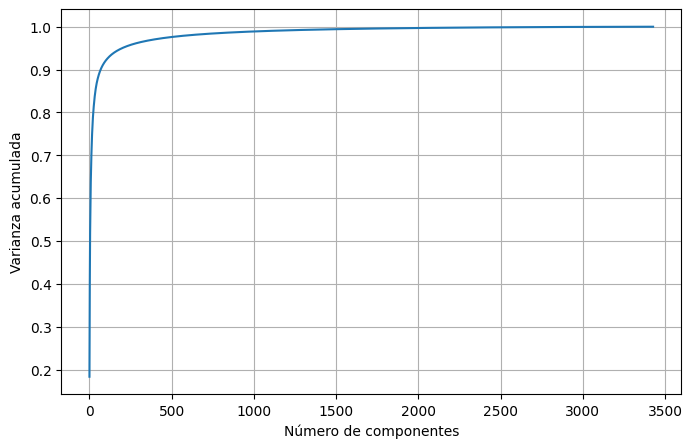

In [172]:
# Probar número de componentes para preservar la varianza
from sklearn.decomposition import PCA
import numpy as np

pca_temp = PCA()
pca_temp.fit(X_train)

var_acum = np.cumsum(
    pca_temp.explained_variance_ratio_
)

plt.figure(figsize=(8,5))
plt.plot(var_acum)
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.grid()
plt.show()

In [173]:
# ETAPA 5: PCA usando SVD
from sklearn.decomposition import PCA

pca = PCA(n_components=50, random_state=42)

# El PCA se "ajusta" (fit) SOLO con datos de entrenamiento
X_train_pca = pca.fit_transform(X_train)

# Al test set solo se le aplica la transformación ya aprendida (transform, no fit)
X_test_pca = pca.transform(X_test)

print("Antes:", X_train.shape)
print("Después:", X_train_pca.shape)

# Cuánta información (varianza) se conserva con 50 componentes
print("Varianza explicada total:", pca.explained_variance_ratio_.sum())

Antes: (3428, 16384)
Después: (3428, 50)
Varianza explicada total: 0.87701535


In [174]:
# Etapa 6,7,8 Geometria computacional por KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train_pca,
    y_train
)

y_pred = knn.predict(
    X_test_pca
)

In [175]:
# ETAPA 9: Evaluación
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print("Matriz de confusión:")
print(cm)

Accuracy:  0.6690
Precision: 0.6913
Recall:    0.6913
F1-score:  0.6913
Matriz de confusión:
[[256 142]
 [142 318]]


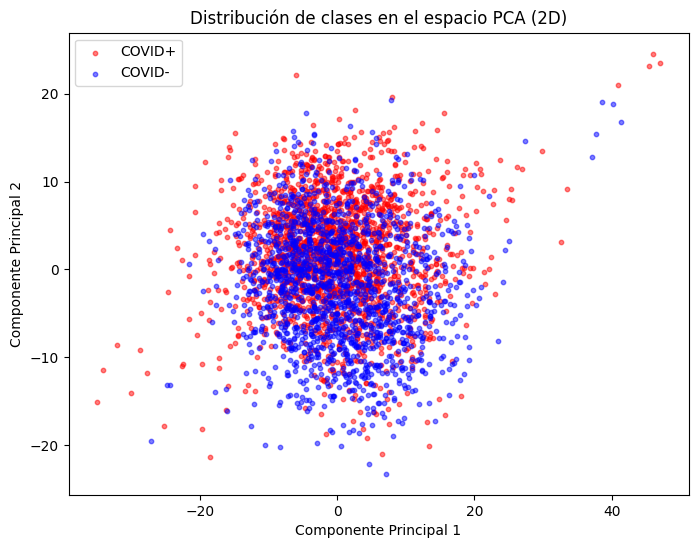

In [176]:
# ETAPA 10: Visualización

# PCA a 2 componentes, ajustado SOLO con datos de entrenamiento (mismo criterio que antes)
pca_2d = PCA(n_components=2, random_state=42)
X_train_2d = pca_2d.fit_transform(X_train)

plt.figure(figsize=(8,6))
plt.scatter(X_train_2d[y_train==1, 0], X_train_2d[y_train==1, 1],
            c='red', label='COVID+', alpha=0.5, s=10)
plt.scatter(X_train_2d[y_train==0, 0], X_train_2d[y_train==0, 1],
            c='blue', label='COVID-', alpha=0.5, s=10)

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Distribución de clases en el espacio PCA (2D)')
plt.legend()
plt.show()

In [177]:
print(pca_2d.explained_variance_ratio_)
print(pca_2d.explained_variance_ratio_.sum())

[0.18350084 0.12655784]
0.31005868


In [178]:
import numpy as np

outlier_idx = np.where(X_train_2d[:,0] > 50)[0]
print(outlier_idx, len(outlier_idx))

# como X_train_2d viene de X_train (vectorizado), necesitas el índice original
for i in outlier_idx[:5]:
    img = X_train[i].reshape(128,128)  # según tu redimensionado a 128x128
    plt.imshow(img, cmap='gray')
    plt.title(f"Outlier idx {i}, label={y_train[i]}")
    plt.show()

[] 0


In [179]:
outlier_idx = np.where(X_train_2d[:,0] > 50)[0]
resto_idx   = np.where(X_train_2d[:,0] <= 50)[0]

print("Brillo medio - outliers:", X_train[outlier_idx].mean())
print("Brillo medio - resto:   ", X_train[resto_idx].mean())

print("Fracción píxeles en 0 - outliers:", (X_train[outlier_idx]==0).mean())
print("Fracción píxeles en 0 - resto:   ", (X_train[resto_idx]==0).mean())

import pandas as pd
print("Distribución de clase en outliers:")
print(pd.Series(y_train[outlier_idx]).value_counts())
print("Distribución de clase en el resto:")
print(pd.Series(y_train[resto_idx]).value_counts())

Brillo medio - outliers: nan
Brillo medio - resto:    0.53845125
Fracción píxeles en 0 - outliers: nan


C:\Users\NR.PandoC\AppData\Local\Temp\ipykernel_18116\2380182239.py:4: RuntimeWarning: Mean of empty slice.
  print("Brillo medio - outliers:", X_train[outlier_idx].mean())
c:\Program Files\Python311\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\NR.PandoC\AppData\Local\Temp\ipykernel_18116\2380182239.py:7: RuntimeWarning: Mean of empty slice.
  print("Fracción píxeles en 0 - outliers:", (X_train[outlier_idx]==0).mean())
c:\Program Files\Python311\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Fracción píxeles en 0 - resto:    0.01111705161309437
Distribución de clase en outliers:
Series([], Name: count, dtype: int64)
Distribución de clase en el resto:
1.0    1839
0.0    1589
Name: count, dtype: int64


In [180]:
# ETAPA 11: Guardar modelos entrenados (para usar en Streamlit u otras apps)
import joblib

joblib.dump(pca, "pca_model.pkl")
joblib.dump(knn, "knn_model.pkl")
print("Modelos guardados: pca_model.pkl, knn_model.pkl")

Modelos guardados: pca_model.pkl, knn_model.pkl


In [181]:
# ETAPA 12: Función de predicción para una radiografía nueva
import cv2
import numpy as np

def predecir_radiografia(ruta_imagen, pca, knn):
    # IMREAD_UNCHANGED preserva la profundidad de bits real del archivo.
    # (IMREAD_GRAYSCALE, en cambio, SIEMPRE fuerza 8 bits, sin importar el origen)
    img = cv2.imread(ruta_imagen, cv2.IMREAD_UNCHANGED)

    divisor = 16383.0 if img.dtype == np.uint16 else 255.0
    img = img.astype(np.float32) / divisor

    img = cv2.resize(img, (128, 128))
    vector = img.reshape(1, -1)

    vector_pca = pca.transform(vector)
    pred = knn.predict(vector_pca)[0]
    proba = knn.predict_proba(vector_pca)[0]

    resultado = "COVID+" if pred == 1 else "COVID-"
    print(f"Predicción: {resultado} (confianza: {proba.max():.2%})")
    return pred

# Ejemplo de uso:
# predecir_radiografia("radiografia_prueba.png", pca, knn)

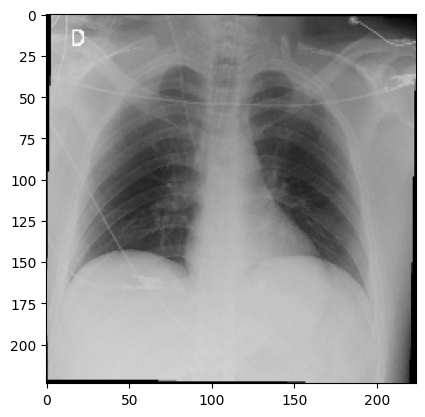

In [184]:
plt.imshow(X_neg224[100], cmap='gray')
plt.show()

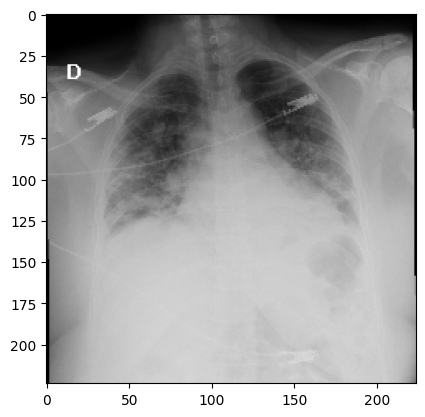

In [185]:
plt.imshow(X_pos224[100], cmap='gray')
plt.show()